In [2]:
import datetime
import sys, os, logging

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from pathlib import Path

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Project root
PROJECT_ROOT = Path(os.path.abspath("../../.."))
sys.path.insert(0, str(PROJECT_ROOT))

from inference.prefilter_model.utils import list_h5_parts, load_model, load_mc_test_parts, \
    load_exp_parts, predict_scores, plot_event_3d, load_blind_reco

%load_ext autoreload
%autoreload 2

In [ ]:
# ── Paths ──

MODEL_NAME = "da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.0_MC2M_dmodel128_zflipBothMCExp_FocalLoss"
CHECKPOINT_PATH = f"experiments/numu/{MODEL_NAME}/best_da_model.pth"

EXP_RECO_H5_PATH = "data_manager/data/h5datasets/exp_reco.h5"
BLIND_ANALYSIS_ROOTS = "data_manager/data/exp_reco_root/reco_blind_files"

# ── Figures output directory ──
TIMESTAMP_STR = datetime.datetime.now().strftime("%y%m%d_%H%M%S")
FIGURES_DIR = PROJECT_ROOT / f"experiments/numu/{MODEL_NAME}/test_reco_figures_{TIMESTAMP_STR}"
#FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str, rewrite=True) -> None:
    """Save figure to FIGURES_DIR; raise FileExistsError if already present."""
    fig_path = FIGURES_DIR / filename
    if not rewrite and fig_path.exists():
        raise FileExistsError(f"Figure already exists: {fig_path}")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")

# ── MC test parts to load (from complement of training parts) ──
N_PARTS_PER_PARTICLE = {
    "muatm": 16,
    "nue2": 8,
    "nuatm": 8,
}

reco_parts = list_h5_parts(str(PROJECT_ROOT / EXP_RECO_H5_PATH), 'exp_reco')
BAD_RECO_PARTS = [
    p for p in reco_parts if 'c01' in p
]

# ── Inference settings ──
DEVICE = "cuda:4"
BATCH_SIZE = 1024
MAX_HITS = 500
SEED = 42

# ── reco_prty column mapping (index -> name) (jsut in case) ──
RECO_EVENTS_COLUMNS = {
    0: "fThetaRec",
    1: "fPhiRec",
    2: "fThetaErr",
    3: "fPhiErr",
    4: "fFuncValue",
    5: "fTimeChi2",
    6: "fChargeTerm",
    7: "fLLFit",
    8: "fNHits",
    9: "fNStrings",
    10: "fNOMs",
    11: "fPathLength",
    12: "fTimeXYZRec",
    13: "fCovMatrixStatus",
    14: "fScfMaxTheta",
    15: "fScfMinTheta",
    16: "fScfTheta",
    17: "fScfPhi",
    18: "fPHit",
    19: "fEvCenterZ",
    20: "fZDist",
    21: "fNTriplets",
    22: "fNCalls",
    23: "fClassBDT", # Just placeholders...
    24: "fClassBDTLowE", # Just placeholders...
}
RECO_HITS_COLUMNS = { 
    0: "fTRes" # Unmatchable with other hits data!!!
}

# Load data

## Full exp reco data (with pulses)

In [4]:
df_exp_reco = load_exp_parts(
    h5_path=str(PROJECT_ROOT / EXP_RECO_H5_PATH),
    group_name="exp_reco",
    max_parts=None,
    load_reco=True,
)
print(f"Exp: {len(df_exp_reco):,} events")
print(df_exp_reco[['season', 'cluster', 'run', 'event_id_cc', 'n_hits']].head(3))

Exp exp_reco:   0%|          | 0/370 [00:00<?, ?part/s]

2026-04-17 11:35:33,523 INFO Loaded 14,447,866 events from /home/albert/Baikal2025/data_manager/data/h5datasets/exp_reco.h5 (exp_reco)


Exp: 14,447,866 events
   season  cluster  run  event_id_cc  n_hits
0    2020        1    1          137      70
1    2020        1    1          234      81
2    2020        1    1          298      77


In [5]:
df_exp_reco = df_exp_reco[(~df_exp_reco['h5_part_str'].isin(BAD_RECO_PARTS))]
## Filter events having max Q >1e4 ev
maxq = np.array([x[:, 0].max() for x in df_exp_reco['features']])
df_exp_reco = df_exp_reco[maxq <= 1e4].reset_index(drop=True)

In [6]:
df_exp_reco

,h5_part_str,local_id,n_hits,features,signal_mask,reco_hit_prty,n_signal_hits_reco,n_signal_strings_reco,season,cluster,...,scfMinTheta,scfTheta,scfPhi,pHit,evCenterZ,zDist,nTriplets,nCalls,classBDT,classBDTLowE
0,part_s2020_c02_r0006,0,74,"[[1.0810608, -2412.8992, 43.481026, -42.363728...","[False, False, False, False, False, False, Fal...","[[0], [0], [0], [0], [0], [0], [0], [4], [3], ...",7,2,2020,2,...,2.722713,2.932152,5.445424,0.000039,527.154663,249.936829,4.0,68.0,-2.0,-2.0
1,part_s2020_c02_r0006,1,65,"[[0.84191924, -2627.6042, -54.021675, 19.39765...","[False, False, False, False, False, False, Fal...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...",7,2,2020,2,...,1.675516,2.199115,3.979349,0.000324,362.530304,75.767693,1.0,57.0,-2.0,-2.0
2,part_s2020_c02_r0006,2,70,"[[1.147976, -2352.7312, -54.106514, 19.400003,...","[False, False, False, False, False, False, Fal...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...",2,1,2020,2,...,1.675516,2.199115,5.340704,0.000016,551.104736,140.173630,0.0,84.0,-2.0,-2.0
3,part_s2020_c02_r0006,3,77,"[[1.5453224, -2254.7463, -50.97715, -31.75994,...","[False, False, False, False, False, False, Fal...","[[0], [0], [0], [0], [0], [-2], [0], [0], [0],...",9,2,2020,2,...,1.989675,2.408554,2.303834,0.000027,411.748169,156.481491,1.0,179.0,-2.0,-2.0
4,part_s2020_c02_r0006,4,75,"[[0.89850014, -2621.3152, -54.71244, 19.243876...","[False, False, False, False, False, False, Fal...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...",7,1,2020,2,...,1.675516,2.199115,3.246311,0.000126,349.847504,126.071136,2.0,124.0,-2.0,-2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12997813,part_s2020_c07_r0465,30429,73,"[[0.8889392, -2277.8494, 48.28511, 30.041891, ...","[False, False, False, False, False, False, Fal...","[[0], [0], [0], [0], [0], [3], [0], [0], [0], ...",5,1,2020,7,...,1.570796,2.094395,5.864302,0.000088,548.051025,117.819702,0.0,142.0,-2.0,-2.0
12997814,part_s2020_c07_r0465,30430,58,"[[1.4922581, -2608.769, 0.45539868, 0.69608045...","[False, False, False, False, False, False, Fal...","[[0], [0], [-1], [0], [0], [0], [0], [0], [0],...",6,2,2020,7,...,1.780236,2.303834,3.874629,0.000282,603.059509,134.818329,1.0,67.0,-2.0,-2.0
12997815,part_s2020_c07_r0465,30431,80,"[[1.2570405, -2936.909, -32.146652, -48.176327...","[False, False, False, False, False, False, Fal...","[[0], [0], [0], [0], [0], [0], [0], [0], [0], ...",7,1,2020,7,...,1.989675,2.513274,6.178461,0.001029,300.571106,139.287048,2.0,130.0,-2.0,-2.0
12997816,part_s2020_c07_r0465,30432,88,"[[1.0937694, -2658.5461, -40.457504, 43.105427...","[False, False, False, False, False, False, Fal...","[[0], [-17], [0], [0], [0], [0], [0], [0], [0]...",13,2,2020,7,...,1.884956,2.094395,3.036872,0.000082,417.445618,146.802979,3.0,126.0,-2.0,-2.0


## Blind analysis results

In [7]:
df_analysis = load_blind_reco(
    blind_reco_dir=str(PROJECT_ROOT / BLIND_ANALYSIS_ROOTS),
    prelcuts_only=True,
    max_files=None
)
df_analysis_filt = df_analysis[df_analysis['fPrelCutsPassed'].astype(bool)]

Loading blind reco:   0%|          | 0/1774 [00:00<?, ?file/s]

2026-04-17 11:36:42,089 WARNING Skipping corrupt file murecAnalysis_blind_prelCuts_2020_cl3_run290_scl_nu_DATA2020.root: expected Chunk of length 403,
received 0 bytes from FSSpecSource
for file path /home/albert/Baikal2025/data_manager/data/exp_reco_root/reco_blind_files/murecAnalysis_blind_prelCuts_2020_cl3_run290_scl_nu_DATA2020.root
2026-04-17 11:36:57,761 WARNING Skipping corrupt file murecAnalysis_blind_prelCuts_2020_cl6_run458_scl_nu_DATA2020.root: expected Chunk of length 403,
received 0 bytes from FSSpecSource
for file path /home/albert/Baikal2025/data_manager/data/exp_reco_root/reco_blind_files/murecAnalysis_blind_prelCuts_2020_cl6_run458_scl_nu_DATA2020.root
2026-04-17 11:36:57,763 WARNING Skipping corrupt file murecAnalysis_blind_prelCuts_2020_cl6_run45_scl_nu_DATA2020.root: expected Chunk of length 403,
received 0 bytes from FSSpecSource
for file path /home/albert/Baikal2025/data_manager/data/exp_reco_root/reco_blind_files/murecAnalysis_blind_prelCuts_2020_cl6_run45_scl_nu

## Filter and merge reco exp events to have preliminary cuts

In [8]:
df_main = df_exp_reco.merge(df_analysis_filt, on=['season', 'cluster', 'run', 'event_id_cc'], how='inner')
len(df_main), len(df_analysis_filt), len(df_exp_reco), len(df_analysis)

(15459, 99228, 12997818, 99228)

In [14]:
del df_exp_reco
del df_analysis_filt

# Load model and enrich data with scores

In [9]:
model, norm_config, train_config = load_model(
    str(PROJECT_ROOT / CHECKPOINT_PATH), device=DEVICE
)
print(f"Normalization: means={norm_config['means']}, stds={norm_config['stds']}")
print(f"Model amp_clip: {model.amp_clip:.4f} (normalized) "
      f"= Q≈{model.amp_clip * norm_config['stds'][0] + norm_config['means'][0]:.1f} PE")

print("Prediction...")
df_main["score"] = predict_scores(
    model, df_main["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
)
print(f"Exp reco scores: mean={df_main['score'].mean():.4f}, median={df_main['score'].median():.4f}")

2026-04-17 11:37:10,003 INFO Created AttentionFeatureExtractor: 5→128, 4 layers, 4 heads, pooling=cls
2026-04-17 11:37:10,006 INFO Created BinaryClassifier: 128→[32, 16]→1, dropout=0.0, batch_norm=False
2026-04-17 11:37:10,007 INFO Created StandardNeutrinoModel with 404161 parameters
2026-04-17 11:37:10,010 INFO amp_clip: Q=100 PE → normalized=1.6333 (mean=2.0, std=60.0)
2026-04-17 11:37:10,014 INFO Loaded model from epoch 47 (best_metric=0.9982)


Normalization: means=[2.0, 0.0, 0.0, 0.0, 0.0], stds=[60.0, 1370.0, 40.0, 40.0, 150.0]
Model amp_clip: 1.6333 (normalized) = Q≈100.0 PE
Prediction...


Predicting:   0%|          | 0/16 [00:00<?, ?batch/s]

/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Exp reco scores: mean=0.4759, median=0.4989


# Plots

In [10]:
# ── BDT category masks ───────────────────────────────────────────────────────
bdt = df_main["fBDT_v3_LE"]
mask_nu  = bdt >= 0.4          # BDT-certain neutrinos
mask_mu  = bdt <= -0.4         # BDT-certain muons
mask_unc = (bdt > -0.4) & (bdt < 0.4)   # BDT-uncertain events

n_all = len(df_main)
n_nu, n_mu, n_unc = mask_nu.sum(), mask_mu.sum(), mask_unc.sum()

print(f"Total prelim-cut events : {n_all:,}")
print(f"  BDT ≥  0.4 (ν-like)  : {n_nu:,}  ({100*n_nu/n_all:.1f}%)")
print(f"  BDT ≤ -0.4 (μ-like)  : {n_mu:,}  ({100*n_mu/n_all:.1f}%)")
print(f"  |BDT| < 0.4 (unclear) : {n_unc:,}  ({100*n_unc/n_all:.1f}%)")

Total prelim-cut events : 15,459
  BDT ≥  0.4 (ν-like)  : 20  (0.1%)
  BDT ≤ -0.4 (μ-like)  : 105  (0.7%)
  |BDT| < 0.4 (unclear) : 15,334  (99.2%)


Text(0.5, 0, '$p_\\nu$')

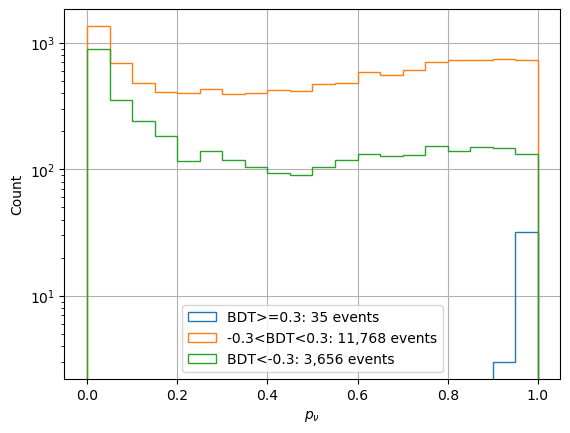

In [ ]:
bdt_cut_min, bdt_cut_max = -0.3, 0.3
df_main['score'][bdt>=bdt_cut_max].hist(range=(0,1), bins=20, density=False, log=True, histtype='step', label=f"BDT>={bdt_cut_max}: {(bdt>=bdt_cut_max).sum():,} events")
df_main['score'][(bdt<bdt_cut_max)&(bdt>=bdt_cut_min)].hist(range=(0,1), bins=20, density=False, log=True, histtype='step', label=f"{bdt_cut_min}<BDT<{bdt_cut_max}: {((bdt<bdt_cut_max)&(bdt>=bdt_cut_min)).sum():,} events")
df_main['score'][(bdt<bdt_cut_min)].hist(range=(0,1), bins=20, density=False, log=True, histtype='step', label=f"BDT<{bdt_cut_min}: {(bdt<bdt_cut_min).sum():,} events")
plt.legend()
plt.ylabel("Count")
plt.xlabel(r"$p_\nu$")

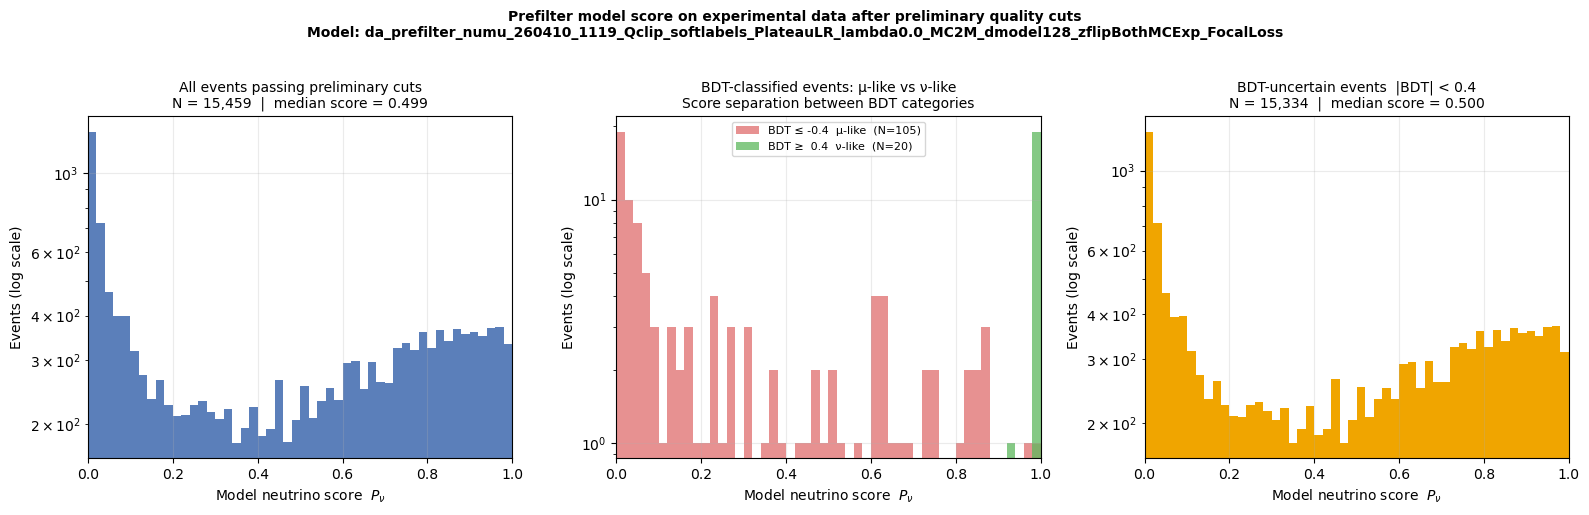

In [12]:
%matplotlib inline
BINS = 50

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)
hist_kw = dict(bins=BINS, range=(0, 1), histtype="bar", edgecolor="none")

# ── Panel 1: All prelim-cut events ───────────────────────────────────────────
axes[0].hist(df_main["score"], log=True, color="#5b7fba", **hist_kw)
axes[0].set_title(
    f"All events passing preliminary cuts\n"
    f"N = {n_all:,}  |  median score = {df_main['score'].median():.3f}",
    fontsize=10,
)

# ── Panel 2: BDT-certain ν vs BDT-certain μ (overlaid) ───────────────────────
axes[1].hist(df_main[mask_mu]["score"],  log=True, color="#e06c6c", alpha=0.75,
             label=f"BDT ≤ -0.4  μ-like  (N={n_mu:,})", **hist_kw)
axes[1].hist(df_main[mask_nu]["score"],  log=True, color="#5cb85c", alpha=0.75,
             label=f"BDT ≥  0.4  ν-like  (N={n_nu:,})", **hist_kw)
axes[1].set_title(
    f"BDT-classified events: μ-like vs ν-like\n"
    f"Score separation between BDT categories",
    fontsize=10,
)
axes[1].legend(fontsize=8)

# ── Panel 3: BDT-uncertain events ────────────────────────────────────────────
axes[2].hist(df_main[mask_unc]["score"], log=True, color="#f0a500", **hist_kw)
axes[2].set_title(
    f"BDT-uncertain events  |BDT| < 0.4\n"
    f"N = {n_unc:,}  |  median score = {df_main[mask_unc]['score'].median():.3f}",
    fontsize=10,
)

for ax in axes:
    ax.set_xlabel("Model neutrino score  $P_{\\nu}$", fontsize=10)
    ax.set_ylabel("Events (log scale)", fontsize=10)
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.25)

fig.suptitle(
    f"Prefilter model score on experimental data after preliminary quality cuts\n"
    f"Model: {MODEL_NAME}",
    fontsize=10, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

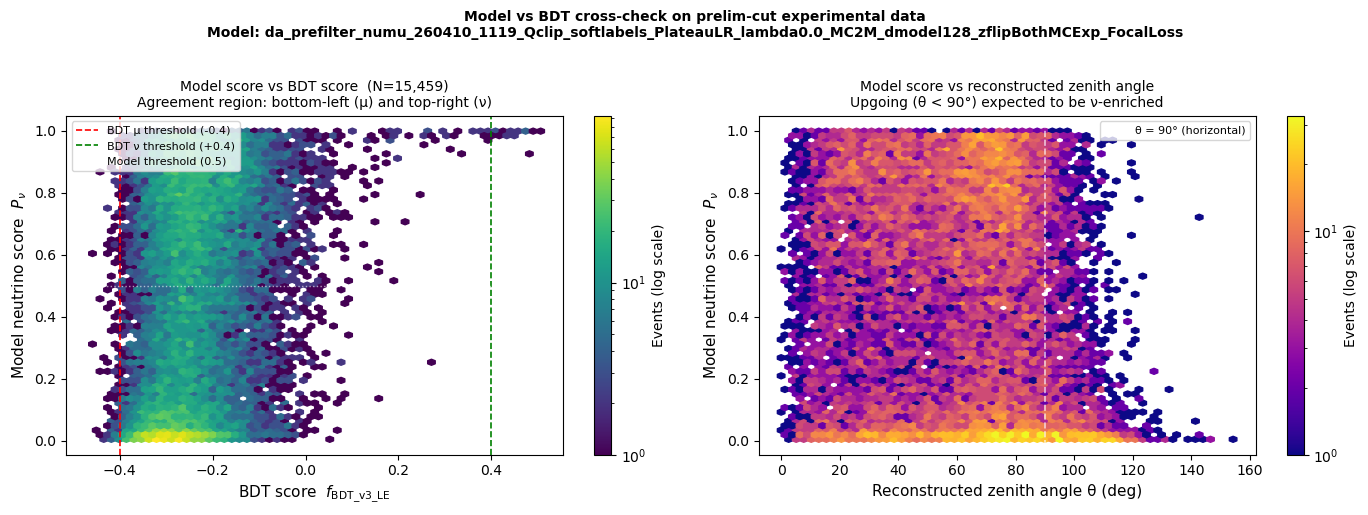

In [13]:
%matplotlib inline

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: 2D hexbin — model score vs BDT score ────────────────────────────
ax = axes[0]
hb = ax.hexbin(
    df_main["fBDT_v3_LE"], df_main["score"],
    gridsize=60, cmap="viridis", bins="log", mincnt=1,
)
fig.colorbar(hb, ax=ax, label="Events (log scale)")
ax.axvline(-0.4, color="red",   lw=1.2, ls="--", label="BDT μ threshold (-0.4)")
ax.axvline( 0.4, color="green", lw=1.2, ls="--", label="BDT ν threshold (+0.4)")
ax.axhline( 0.5, color="white", lw=1.0, ls=":",  alpha=0.6, label="Model threshold (0.5)")
ax.set_xlabel("BDT score  $f_{\\mathrm{BDT\\_v3\\_LE}}$", fontsize=11)
ax.set_ylabel("Model neutrino score  $P_{\\nu}$", fontsize=11)
ax.set_title(
    f"Model score vs BDT score  (N={n_all:,})\n"
    f"Agreement region: bottom-left (μ) and top-right (ν)",
    fontsize=10,
)
ax.legend(fontsize=8, loc="upper left")

# ── Panel 2: model score vs reco theta (upgoing/downgoing separation) ─────────
ax = axes[1]
hb2 = ax.hexbin(
    df_main["thetaRec"], df_main["score"],
    gridsize=60, cmap="plasma", bins="log", mincnt=1,
)
fig.colorbar(hb2, ax=ax, label="Events (log scale)")
ax.axvline(90, color="white", lw=1.2, ls="--", alpha=0.7, label="θ = 90° (horizontal)")
ax.set_xlabel("Reconstructed zenith angle θ (deg)", fontsize=11)
ax.set_ylabel("Model neutrino score  $P_{\\nu}$", fontsize=11)
ax.set_title(
    f"Model score vs reconstructed zenith angle\n"
    f"Upgoing (θ < 90°) expected to be ν-enriched",
    fontsize=10,
)
ax.legend(fontsize=8)

fig.suptitle(
    f"Model vs BDT cross-check on prelim-cut experimental data\n"
    f"Model: {MODEL_NAME}",
    fontsize=10, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()